In [1]:
%load_ext autoreload
%autoreload 2
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import jax_cosmo.background as bkgrd
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from jax.lib import xla_bridge
# platform = xla_bridge.get_backend().platform
import jax
from jaxopt import ScipyBoundedMinimize
from jaxopt import LBFGSB
from jax import value_and_grad

print(jax.local_device_count(), jax.device_count())
# jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax

import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = False
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)


from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl
from get_Xis import get_xi
from get_covs import get_cov
import matplotlib.pyplot as pl
from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import copy
import jax.numpy as jnp
import colossus 
from jax import vmap, grad, pmap
import matplotlib.pyplot as pl
import jax_cosmo.background as bkgrd
import time
from jax_cosmo import Cosmology
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance
from astropy import constants as const
pl.rc('text', usetex=True)
import getdist
from getdist import plots, MCSamples

from tqdm import tqdm
import copy
import numpyro
numpyro.set_platform("gpu")
numpyro.enable_x64()
numpyro.set_host_device_count(jax.device_count())
from numpyro.handlers import seed, trace, condition
# Now we condition the model on obervations


import numpyro
from numpyro.infer.reparam import LocScaleReparam, TransformReparam

def config(x):
    if type(x['fn']) is dist.TransformedDistribution:
        return TransformReparam()
    elif type(x['fn']) is dist.Normal and ('decentered' not in x['name']):
        return LocScaleReparam(centered=0)
    else:
        return None


from numpyro.distributions.transforms import AffineTransform
import numpyro.distributions as dist
import numpyro
def Uniform(name, min_value, max_value):
    """ Creates a Uniform distribution in target range from a base
    distribution between [-3, 3]
    """
    s = (max_value - min_value) / 6.
    return numpyro.sample(
            name,
            dist.TransformedDistribution(
                dist.Uniform(-3., 3.),
                AffineTransform(min_value + 3.*s, s),
            ),
        )

from numpyro.infer import HMC, HMCECS, MCMC, NUTS, SA, SVI, Trace_ELBO, init_to_value


# ell_min = int(sys.argv[1])
# ell_max = int(sys.argv[2])
# num_warmup = int(sys.argv[3])
# num_samples = int(sys.argv[4])
# # Parse bin indices from sys.argv[5], e.g., '[1,2,3]' or '[2]'
# bins_to_fit_str = sys.argv[5] if len(sys.argv) > 5 else '[1,2,3]'

ell_min = 200
ell_max = 3000
num_warmup = 100
num_samples = 100
bins_to_fit_str = '[1,2,3]'

# Convert string to list of integers (1-indexed from user, convert to 0-indexed)
bins_to_fit = [int(b)-1 for b in bins_to_fit_str.strip('[]').split(',')]
print(f"Fitting bins (0-indexed): {bins_to_fit}")


1 1
Fitting bins (0-indexed): [0, 1, 2]


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import yaml
# from deepmerge import always_merger
from deepmerge import Merger
my_merger = Merger(
    [
        (list, ["override"]),  # Override lists instead of appending
        (dict, ["merge"])      # Still merge dictionaries
    ],
    ["override"],  # Default fallback strategy
    ["override"]
)

def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
new_data = read_yaml(abs_path_params + '/xDESI/params_fit_abacus.yaml')
merged_data = my_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)


from scipy.interpolate import interp1d
ks = np.geomspace(3e-1,10,10) # wavenumbers
zarray_lens = np.linspace(0.001, 1.6, 200)


cosmo_params = sim_params_dict.get('cosmo')
cosmo_jax = Cosmology(
            Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
            Omega_b=cosmo_params['Ob0'],
            h=cosmo_params['H0'] / 100.,
            sigma8=cosmo_params['sigma8'],
            n_s=cosmo_params['ns'],
            Omega_k=0.,
            w0=cosmo_params['w0'],
            wa=0.
            )
scale_fac_a_array = 1.0 / (1.0 + zarray_lens)


df_sims = pk.load(open(os.path.abspath(abs_path_data + '/xDESI/abacus_LRG_nz_Clgg_v4_combined_16sims.pkl'), 'rb'))

zvals = df_sims['zvals']
nbins_lens = len(zvals)
delta_zarray = zarray_lens[1] - zarray_lens[0]
zarray_lens_edges = np.concatenate(([zarray_lens[0] - delta_zarray/2], 0.5*(zarray_lens[1:] + zarray_lens[:-1]), [zarray_lens[-1] + delta_zarray/2]))
nz_lens = {}

Ngals_bins = []
for jz, zval_group in enumerate(zvals):    
    Ngals_jz = df_sims['Ngal_all'][f'z{zval_group[0]:.3f}_{zval_group[-1]:.3f}']
    Ngals_bins.append(Ngals_jz)

    zcen_nz_file = df_sims['nz_gal_all']['z_array']
    nz_gal_file = df_sims['nz_gal_all'][f'z{zval_group[0]:.3f}_{zval_group[-1]:.3f}']
    nz_gal_interp = interp1d(zcen_nz_file, nz_gal_file, fill_value=0.0, bounds_error=False)

    hist_z = nz_gal_interp(zarray_lens)
    nz_lens[jz] = hist_z/( np.trapz(hist_z, zarray_lens) )

    nz_comoving = np.zeros_like(zarray_lens)
    indsel = np.where(hist_z > 1e-5)[0]

nbar_comoving_file = df_sims['nbar_comoving']
zcens_comoving_file = df_sims['zcens_comoving']

nbar_interp = interp1d(zcens_comoving_file, nbar_comoving_file, fill_value=1e-8, bounds_error=False)
nbar_array = nbar_interp(zarray_lens)

analysis_dict['nbar_gal_comoving_zarray'] = zarray_lens
analysis_dict['nbar_gal_comoving_val'] = nbar_array


nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = nbins_lens
for ji in range(nz_info_dict['nbins_lens']):
    nz_info_dict['nz'+str(ji)] = np.maximum(nz_lens[ji], 1e-3)
z_edges_lens = []
for ji in range(nz_info_dict['nbins_lens']):
    nz_ji = nz_info_dict['nz'+str(ji)]
    zvals_ji = zarray_lens[np.where(nz_ji > 7e-1)[0]]
    z_edges_lens.append(np.array([zvals_ji[0], zvals_ji[-1]]))
z_edges_lens = np.array(z_edges_lens)
nz_info_dict['z_edges_bins_lens'] = z_edges_lens
analysis_dict['nz_lens_info_dict'] = nz_info_dict


from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 1
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]
analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0']/100.))

lmin, lmax, dl_log_array = 80.0, 8800.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)

analysis_dict['nbar_lens_bins'] = np.array(Ngals_bins)/(analysis_dict['fsky_gg']*41253*(60**2))

analysis_dict['symbolic_pk'] = True
analysis_dict['symbolic_hmf'] = True


base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)


df_sims = pk.load(open(os.path.abspath(abs_path_data + '/xDESI/abacus_LRG_nz_Clgg_v4_combined_16sims.pkl'), 'rb'))
Cls_sims = df_sims['Cl_gg_all']
len_tot_ell = len(Cls_sims['l_array'])


l_array_sims = jnp.array(Cls_sims['l_array'])
indsel_ell = jnp.where((l_array_sims >= ell_min) & (l_array_sims <= ell_max))[0]
l_array_sims = l_array_sims[indsel_ell]

# Map bin indices to redshift keys
bin_to_zkey = {
    0: 'z0.300_0.400',
    1: 'z0.450_0.575',
    2: 'z0.650_0.800'
}

# Load data only for selected bins
Cl_gg_sims_dict = {}
cov_gaussian_dict = {}
Cls_std_sims = df_sims['Cl_gg_all_std']

for bin_idx in bins_to_fit:
    zkey = bin_to_zkey[bin_idx]
    Cl_gg_sims_dict[bin_idx] = jnp.array(Cls_sims[zkey][indsel_ell])
    cov_gaussian_dict[bin_idx] = jnp.array(Cls_std_sims[zkey][indsel_ell])**2

print(l_array_sims[0], l_array_sims[-1])

# Concatenate data for selected bins only
data_vec_list = [Cl_gg_sims_dict[bin_idx] for bin_idx in bins_to_fit]
data_vec = jnp.concatenate(data_vec_list, axis=0)

# Concatenate covariances for selected bins only
cov_list = [cov_gaussian_dict[bin_idx] for bin_idx in bins_to_fit]
sig_total_combined = jnp.sqrt(jnp.concatenate(cov_list, axis=0))
cov_total = jnp.diag(sig_total_combined**2)



# Build plot data for selected bins only
plot_data = {
    'l_array_sims': l_array_sims,
    'bins_to_fit': bins_to_fit
}

# Add data and model predictions for each selected bin
for bin_idx in bins_to_fit:
    plot_data[f'Cl_gg_sims{bin_idx}'] = Cl_gg_sims_dict[bin_idx]
    plot_data[f'cov_gaussian_{bin_idx}'] = cov_gaussian_dict[bin_idx]
    logClgg_sims_interp = jnp.exp(jnp.interp(jnp.log(l_array_sims), jnp.log(Cls_test.ell_array), jnp.log(Cls_test.Cl_gal_gal_tot_mat[:,bin_idx,bin_idx])))
    plot_data[f'logClgg_sims_interp{bin_idx}'] = logClgg_sims_interp

# saved = {'samps': samps, 'names': names, 'labels': [latex_vars[param][0] for param in names], 'chi2_good': chi2_good, 'param_vary_names_final': param_vary_names_final, 'xmin': xmin, 'lower_bounds_dict': lower_bounds_dict, 'upper_bounds_dict': upper_bounds_dict, 'plot_data': plot_data, 'bins_to_fit': bins_to_fit}

# Create filename with bin information
# bins_str = '_'.join([str(b+1) for b in bins_to_fit])  # Convert back to 1-indexed for filename




301.5 2901.5


In [3]:
%matplotlib inline
# import corner

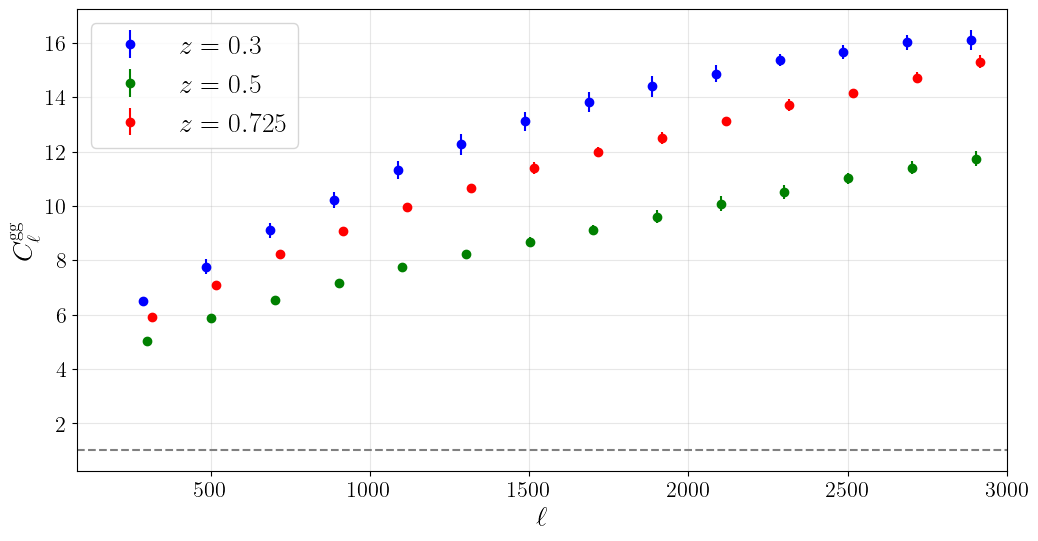

In [5]:
colors = ['blue', 'green', 'red']
pl.figure(figsize=(12,6))
pl.errorbar(plot_data['l_array_sims']-15, plot_data['Cl_gg_sims0']/plot_data['logClgg_sims_interp0'], yerr=np.sqrt(plot_data['cov_gaussian_0'])/plot_data['logClgg_sims_interp0'], fmt='o', color=colors[0], label=r'$z=0.3$')
pl.errorbar(plot_data['l_array_sims'], plot_data['Cl_gg_sims1']/plot_data['logClgg_sims_interp1'], yerr=np.sqrt(plot_data['cov_gaussian_1'])/plot_data['logClgg_sims_interp1'], fmt='o', color=colors[1], label=r'$z=0.5$')
pl.errorbar(plot_data['l_array_sims']+15, plot_data['Cl_gg_sims2']/plot_data['logClgg_sims_interp2'], yerr=np.sqrt(plot_data['cov_gaussian_2'])/plot_data['logClgg_sims_interp2'], fmt='o', color=colors[2], label=r'$z=0.725$')
pl.grid(alpha=0.3)
# pl.ylim(0.8, 1.2)
pl.xlim(80, 3000)
# set tick label sizes:
pl.xticks(fontsize=16)
pl.yticks(fontsize=16)
pl.axhline(1.0, color='gray', linestyle='--')
pl.xlabel(r'$\ell$', fontsize=20)
pl.ylabel(r'$C_\ell^{\mathrm{gg}}$', fontsize=20)
pl.legend(fontsize=20)
pl.show()




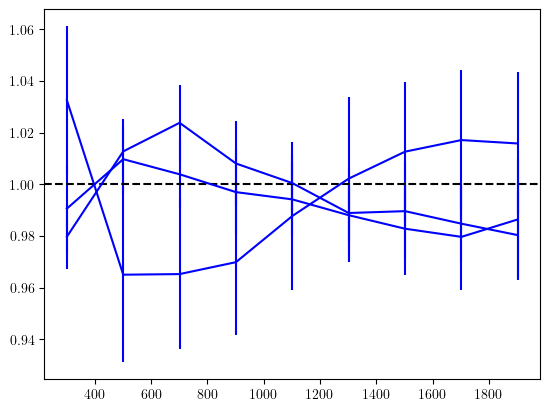

In [ ]:
import matplotlib.pyplot as pl
%matplotlib inline
pl.figure()

for jb in range(len(bins_to_fit)):
    pl.errorbar(l_array_sims, plot_data['Cl_gg_sims'+str(bins_to_fit[jb])]/plot_data[f'logClgg_sims_interp{bins_to_fit[jb]}'], yerr=np.sqrt(plot_data[f'cov_gaussian_{bins_to_fit[jb]}'])/plot_data[f'logClgg_sims_interp{bins_to_fit[jb]}'],  label='Data bin '+str(bins_to_fit[jb]+1), color=colors[0])
pl.axhline(1.0, color='black', linestyle='--')
pl.show()




In [17]:
# colors = ['blue', 'green', 'red']
# pl.figure
# pl.plot(Cls_test.ell_array, Cls_test.Cl_gal_gal_tot_mat[:,0,0], color=colors[0], label=r'$z=0.3$')
# pl.errorbar(l_array_sims, Cl_gg_sims0, yerr=np.sqrt(cov_gaussian_0), fmt='o', color=colors[0])

# pl.plot(Cls_test.ell_array, Cls_test.Cl_gal_gal_tot_mat[:,1,1], color=colors[1], label=r'$z=0.5$')
# pl.errorbar(l_array_sims, Cl_gg_sims1, yerr=np.sqrt(cov_gaussian_1), fmt='o', color=colors[1])

# pl.plot(Cls_test.ell_array, Cls_test.Cl_gal_gal_tot_mat[:,2,2], color=colors[2], label=r'$z=0.725$')
# pl.errorbar(l_array_sims, Cl_gg_sims2, yerr=np.sqrt(cov_gaussian_2), fmt='o', color=colors[2])
# pl.xscale('log')
# pl.yscale('log')
# pl.xlabel(r'$\ell$', fontsize=20)
# pl.ylabel(r'$C_\ell^{\mathrm{gg}}$', fontsize=20)
# pl.legend(fontsize=20)
# pl.show()




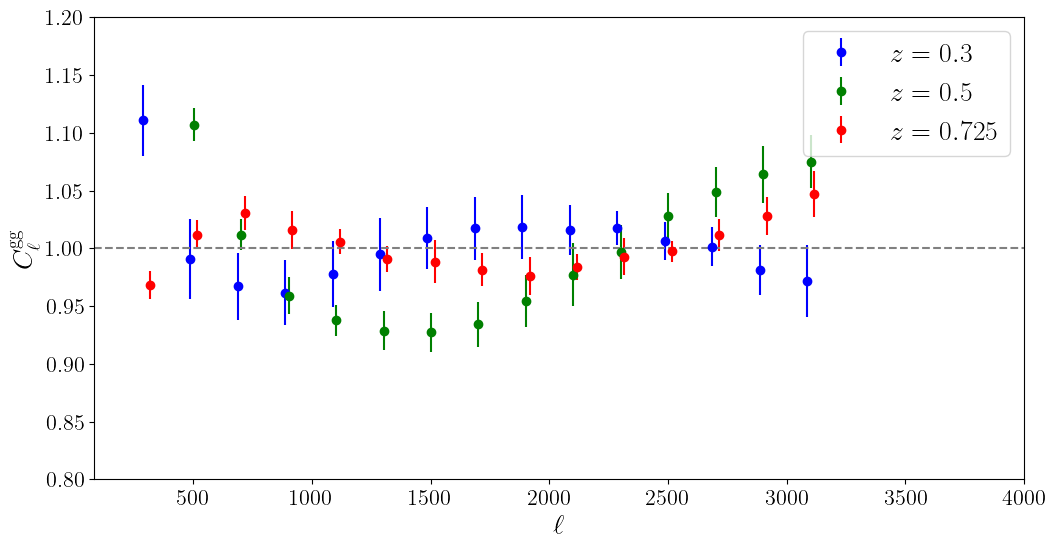

In [13]:
logClgg_sims_interp0 = jnp.exp(jnp.interp(jnp.log(l_array_sims), jnp.log(Cls_test.ell_array), jnp.log(model_good.Cl_gal_gal_tot_mat[:,0,0])))
logClgg_sims_interp1 = jnp.exp(jnp.interp(jnp.log(l_array_sims), jnp.log(Cls_test.ell_array), jnp.log(model_good.Cl_gal_gal_tot_mat[:,1,1])))
logClgg_sims_interp2 = jnp.exp(jnp.interp(jnp.log(l_array_sims), jnp.log(Cls_test.ell_array), jnp.log(model_good.Cl_gal_gal_tot_mat[:,2,2])))


# Cls_test.Cl_gal_gal_tot_mat.shape

colors = ['blue', 'green', 'red']
pl.figure(figsize=(12,6))
pl.errorbar(l_array_sims-15, Cl_gg_sims0/logClgg_sims_interp0, yerr=np.sqrt(cov_gaussian_0)/logClgg_sims_interp0, fmt='o', color=colors[0], label=r'$z=0.3$')
# pl.plot(Cls_test.ell_array, model_good.Cl_gal_gal_tot_mat[:,1,1], color=colors[1], label=r'$z=0.5$')
pl.errorbar(l_array_sims, Cl_gg_sims1/logClgg_sims_interp1, yerr=np.sqrt(cov_gaussian_1)/logClgg_sims_interp1, fmt='o', color=colors[1], label=r'$z=0.5$')
# pl.plot(Cls_test.ell_array, model_good.Cl_gal_gal_tot_mat[:,2,2], color=colors[2], label=r'$z=0.725$')
pl.errorbar(l_array_sims+15, Cl_gg_sims2/logClgg_sims_interp2, yerr=np.sqrt(cov_gaussian_2)/logClgg_sims_interp2, fmt='o', color=colors[2], label=r'$z=0.725$')
# pl.xscale('log')
# pl.yscale('log')
pl.ylim(0.8, 1.2)
pl.xlim(80, 4000)
# set tick label sizes:
pl.xticks(fontsize=16)
pl.yticks(fontsize=16)
pl.axhline(1.0, color='gray', linestyle='--')
pl.xlabel(r'$\ell$', fontsize=20)
pl.ylabel(r'$C_\ell^{\mathrm{gg}}$', fontsize=20)
pl.legend(fontsize=20)
pl.show()




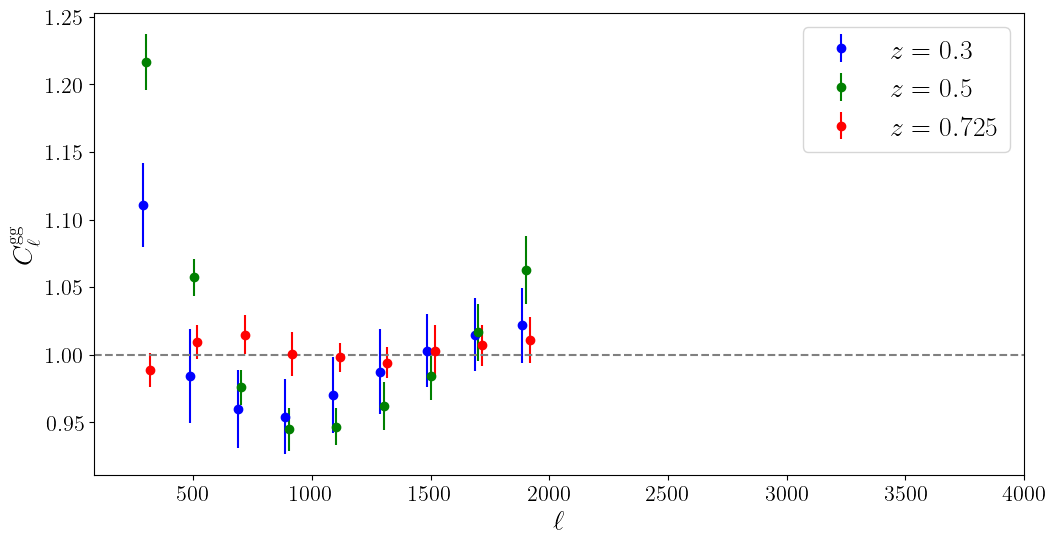

In [4]:
df_file = pk.load(open('/mnt/ceph/users/spandey/paste_godmax/GODMAX/results/xDESI/mcmc_fit_abacus_v4_16sims_deltaell_100_3200samples_ellrange_200_2000_nparams_36.pkl', 'rb'))

plot_data = df_file['plot_data']



# plot_data = {
#     'l_array_sims': l_array_sims,
#     'Cl_gg_sims0': Cl_gg_sims0,
#     'Cl_gg_sims1': Cl_gg_sims1,
#     'Cl_gg_sims2': Cl_gg_sims2,
#     'cov_gaussian_0': cov_gaussian_0,
#     'cov_gaussian_1': cov_gaussian_1,
#     'cov_gaussian_2': cov_gaussian_2,
#     'logClgg_sims_interp0': logClgg_sims_interp0,
#     'logClgg_sims_interp1': logClgg_sims_interp1,
#     'logClgg_sims_interp2': logClgg_sims_interp2
# }

colors = ['blue', 'green', 'red']
pl.figure(figsize=(12,6))
pl.errorbar(plot_data['l_array_sims']-15, plot_data['Cl_gg_sims0']/plot_data['logClgg_sims_interp0'], yerr=np.sqrt(plot_data['cov_gaussian_0'])/plot_data['logClgg_sims_interp0'], fmt='o', color=colors[0], label=r'$z=0.3$')
# pl.plot(Cls_test.ell_array, model_good.Cl_gal_gal_tot_mat[:,1,1], color=colors[1], label=r'$z=0.5$')
pl.errorbar(plot_data['l_array_sims'], plot_data['Cl_gg_sims1']/plot_data['logClgg_sims_interp1'], yerr=np.sqrt(plot_data['cov_gaussian_1'])/plot_data['logClgg_sims_interp1'], fmt='o', color=colors[1], label=r'$z=0.5$')
# pl.plot(Cls_test.ell_array, model_good.Cl_gal_gal_tot_mat[:,2,2], color=colors[2], label=r'$z=0.725$')
pl.errorbar(plot_data['l_array_sims']+15, plot_data['Cl_gg_sims2']/plot_data['logClgg_sims_interp2'], yerr=np.sqrt(plot_data['cov_gaussian_2'])/plot_data['logClgg_sims_interp2'], fmt='o', color=colors[2], label=r'$z=0.725$')
# pl.xscale('log')
# pl.yscale('log')
# pl.ylim(0.8, 1.2)
pl.xlim(80, 4000)
# set tick label sizes:
pl.xticks(fontsize=16)
pl.yticks(fontsize=16)
pl.axhline(1.0, color='gray', linestyle='--')
pl.xlabel(r'$\ell$', fontsize=20)
pl.ylabel(r'$C_\ell^{\mathrm{gg}}$', fontsize=20)
pl.legend(fontsize=20)
pl.show()



Removed no burn in


<Figure size 1825x1825 with 0 Axes>

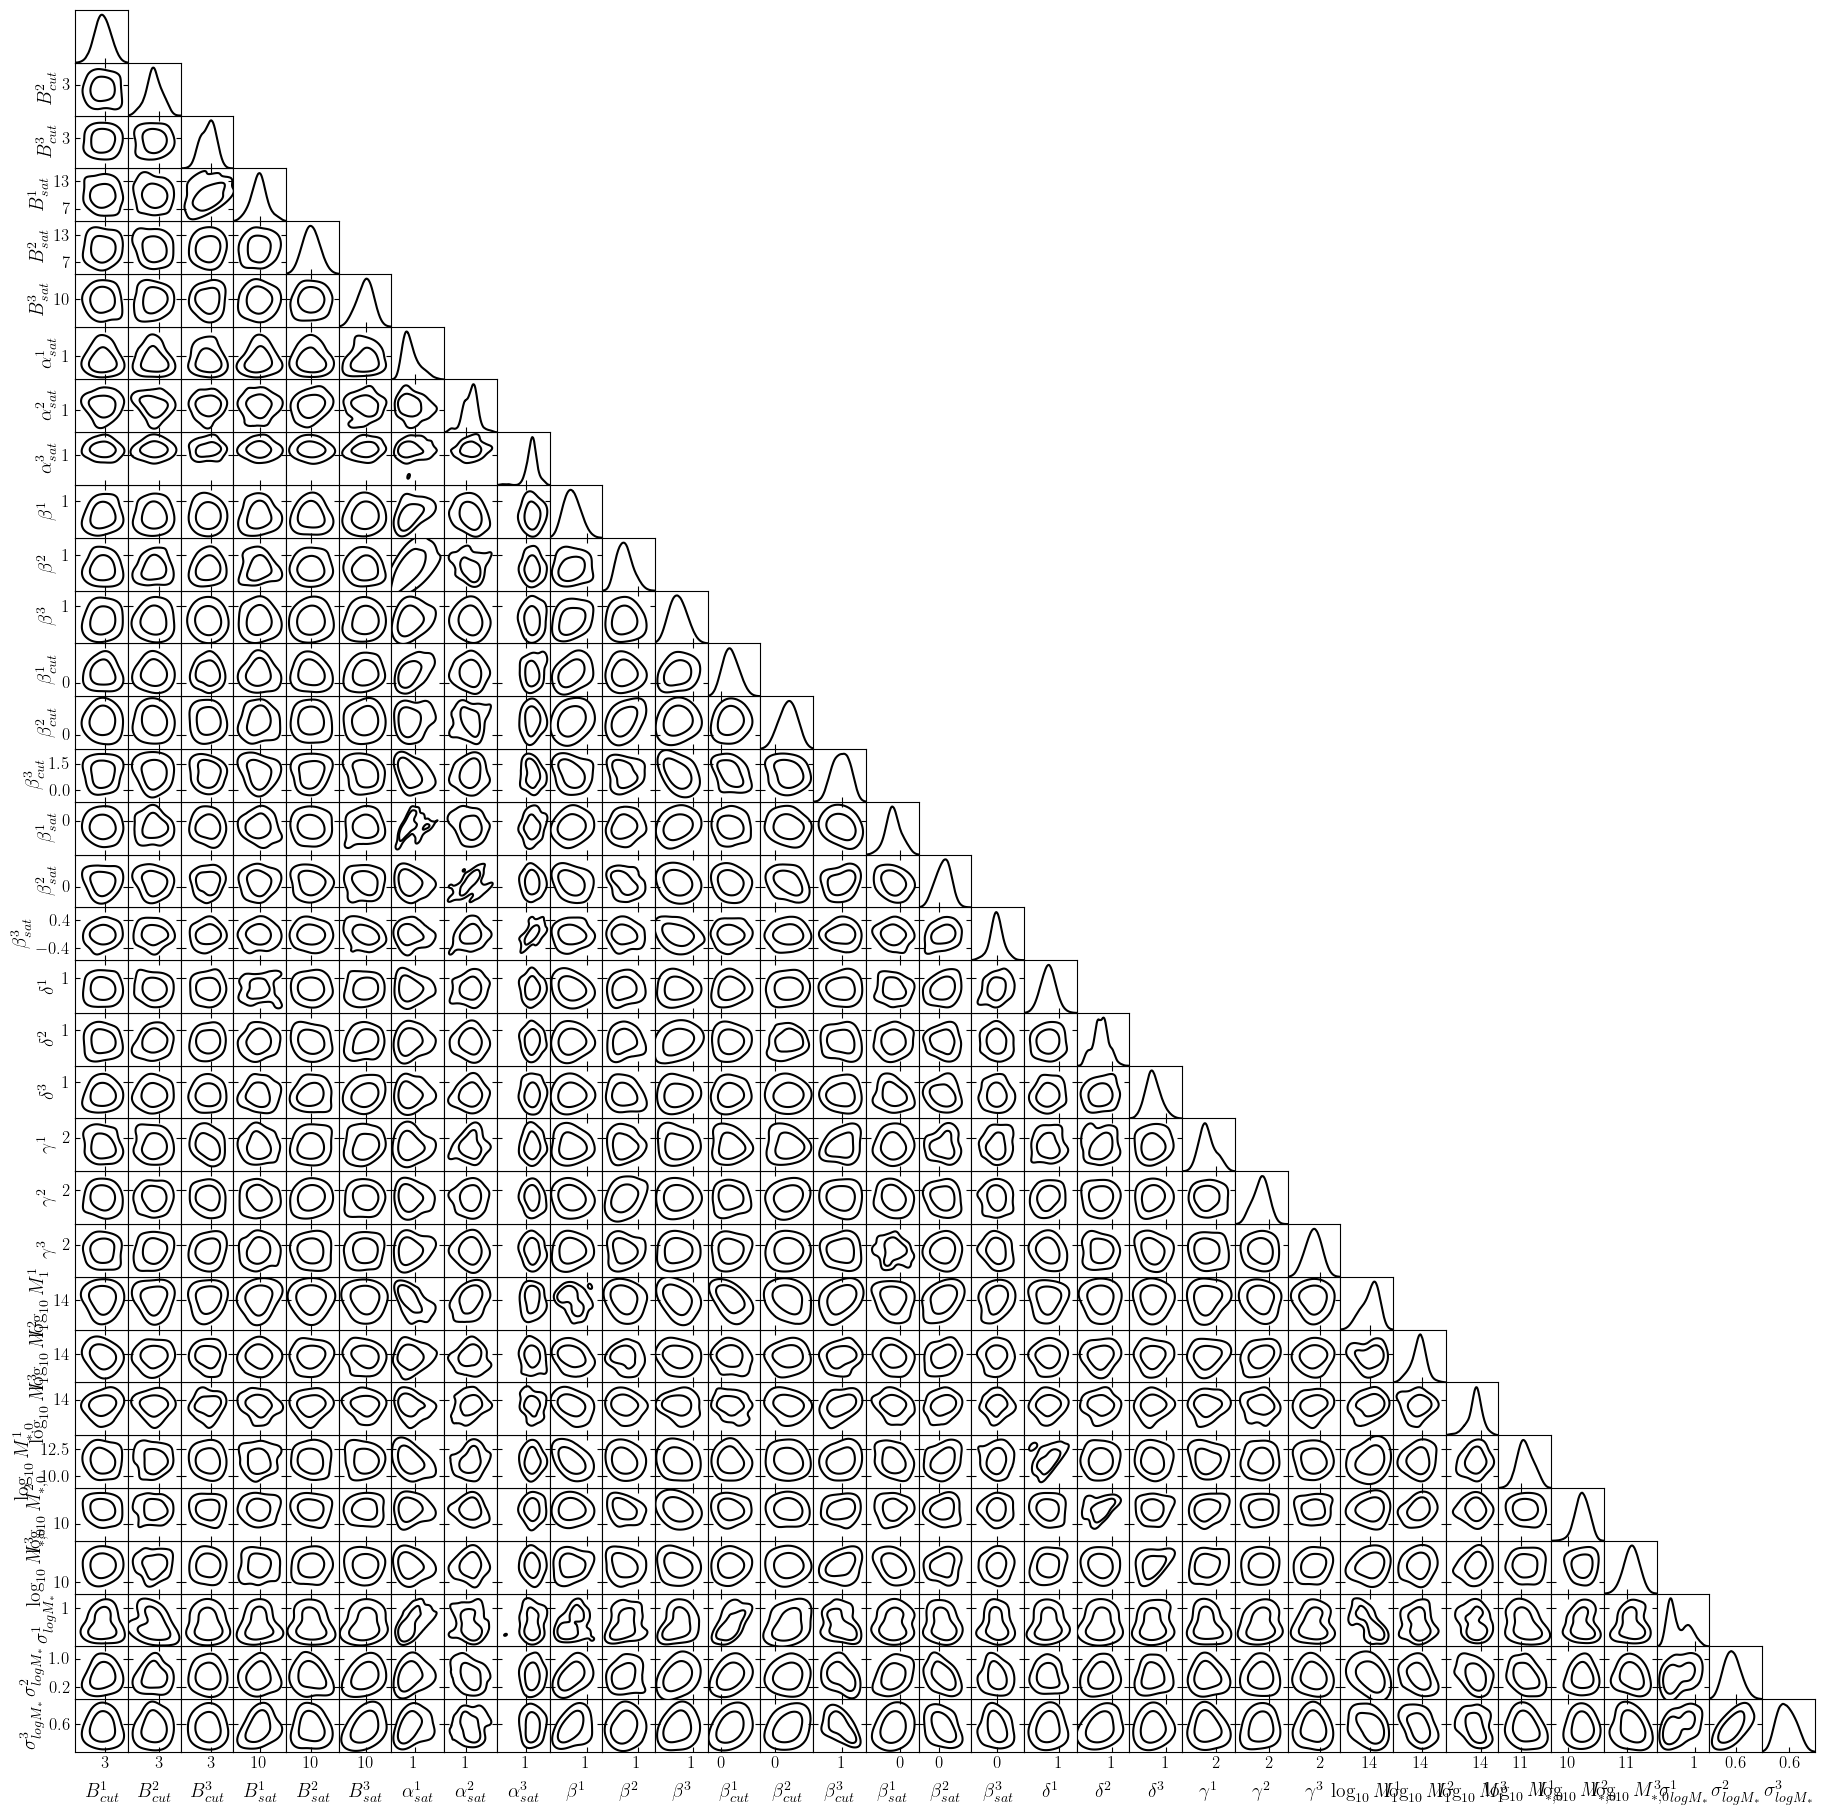

In [43]:
import getdist
from getdist import plots, MCSamples
# df_file['chi2_good'], df_file['param_vary_names_final'], df_file['xmin']
samps, names, labels = df_file['samps'], df_file['names'], df_file['labels']

samps = np.array(samps)
# names = keys
samples = MCSamples(samples=samps,names = names, labels=labels)
params = samples.getParamNames().getRunningNames()


import getdist
from getdist import plots, MCSamples


g = plots.getSinglePlotter(width_inch=18.25, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 18
g.settings.lab_fontsize    = 20
g.settings.legend_fontsize = 20
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

line_args = [{'lw':1.0,'color':'black'},{'lw':1.0, 'ls':'--' ,'color':'blue'},{'lw':1.0,'color':'red'},{'lw':0.1,'color':'orange'},{'lw':0.1,'color':'green'}]

contour_args = {'filled': True, 'alpha': 0.7}


g.triangle_plot([samples], params, line_args=line_args, 
            # labels=[latex_vars[param] for param in params],
            contour_lws=[1.5, 1.5, 1.0], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
            ls=['-','--','','',''])

import matplotlib
%matplotlib inline
pl.show()




In [2]:
import matplotlib.pyplot as pl
%matplotlib inline



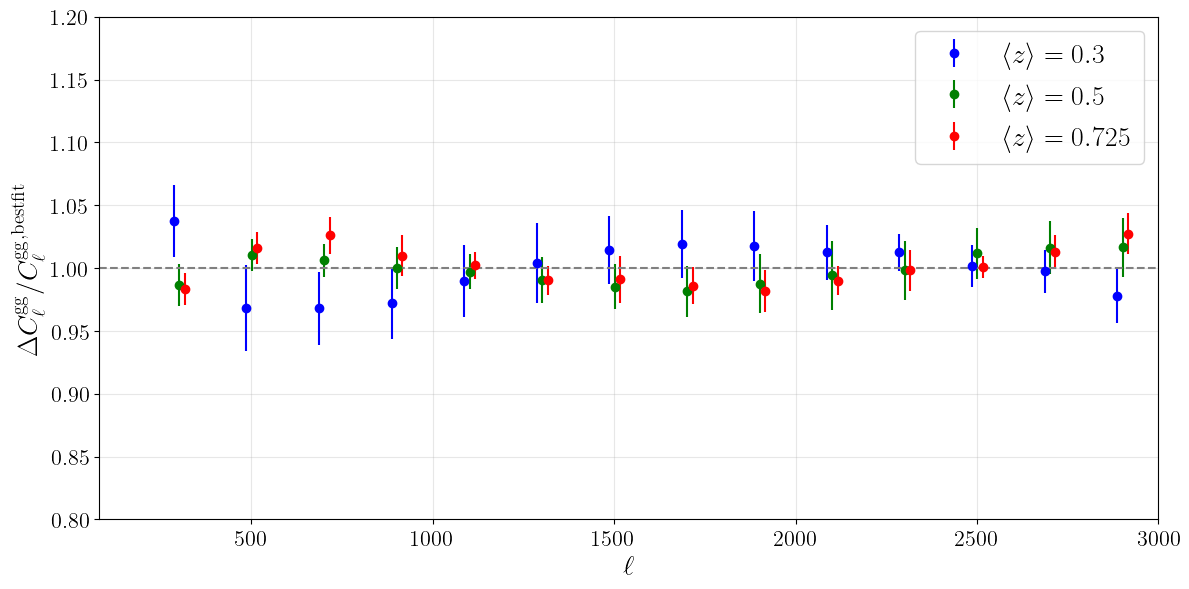

In [6]:
# /mnt/ceph/users/spandey/paste_godmax/GODMAX/results/xDESI/mcmc_fit_abacus_v4_16sims_deltaell_100_800samples_ellrange_200_2000_bins_2_nparams_12_v2.pkl

df_file1 = pk.load(open('/mnt/ceph/users/spandey/paste_godmax/GODMAX/results/xDESI/mcmc_fit_abacus_v4_16sims_deltaell_100_2400samples_ellrange_200_3000_bins_1_nparams_13_v2.pkl', 'rb'))
plot_data1 = df_file1['plot_data']

df_file2 = pk.load(open('/mnt/ceph/users/spandey/paste_godmax/GODMAX/results/xDESI/mcmc_fit_abacus_v4_16sims_deltaell_100_2400samples_ellrange_200_3000_bins_2_nparams_13_v2.pkl', 'rb'))
plot_data2 = df_file2['plot_data']

df_file3 = pk.load(open('/mnt/ceph/users/spandey/paste_godmax/GODMAX/results/xDESI/mcmc_fit_abacus_v4_16sims_deltaell_100_2400samples_ellrange_200_3000_bins_3_nparams_13_v2.pkl', 'rb'))
plot_data3 = df_file3['plot_data']

# df_file = pk.load(open('/mnt/ceph/users/spandey/paste_godmax/GODMAX/results/xDESI/mcmc_fit_abacus_v4_16sims_deltaell_100_3200samples_ellrange_200_2000_bins_1_2_3_nparams_39_v2.pkl', 'rb'))


colors = ['blue', 'green', 'red']
pl.figure(figsize=(12,6))
pl.errorbar(plot_data1['l_array_sims']-15, plot_data1['Cl_gg_sims0']/plot_data1['logClgg_sims_interp0'], yerr=np.sqrt(plot_data1['cov_gaussian_0'])/plot_data1['logClgg_sims_interp0'], fmt='o', color=colors[0], label=r'$\langle z \rangle=0.3$')

pl.errorbar(plot_data2['l_array_sims'], plot_data2['Cl_gg_sims1']/plot_data2['logClgg_sims_interp1'], yerr=np.sqrt(plot_data2['cov_gaussian_1'])/plot_data2['logClgg_sims_interp1'], fmt='o', color=colors[1], label=r'$\langle z \rangle=0.5$')

pl.errorbar(plot_data3['l_array_sims']+15, plot_data3['Cl_gg_sims2']/plot_data3['logClgg_sims_interp2'], yerr=np.sqrt(plot_data3['cov_gaussian_2'])/plot_data3['logClgg_sims_interp2'], fmt='o', color=colors[2], label=r'$\langle z \rangle=0.725$')
# pl.xscale('log')
# pl.yscale('log')
# pl.ylim(0.8, 1.2)
pl.xlim(80, 3000)
pl.ylim(0.8, 1.2)
# set tick label sizes:
pl.xticks(fontsize=16)
pl.yticks(fontsize=16)
pl.axhline(1.0, color='gray', linestyle='--')
pl.xlabel(r'$\ell$', fontsize=20)
pl.ylabel(r'$\Delta C_\ell^{\mathrm{gg}}/C^{\mathrm{gg}, \mathrm{bestfit}}_\ell$', fontsize=20)
pl.legend(fontsize=20)
pl.grid(alpha=0.3)
pl.tight_layout()
# pl.savefig(abs_path_results + '/xDESI/plots/Clgg_bestfit_comparison_bins1_2_3.png', dpi=300)
pl.show()




In [7]:
# df_file1.keys()
param_names1, xmin1 = df_file1['param_vary_names_final'], df_file1['xmin']
param_names2, xmin2 = df_file2['param_vary_names_final'], df_file2['xmin']
param_names3, xmin3 = df_file3['param_vary_names_final'], df_file3['xmin']

for jp in range(len(param_names1)):
    name = param_names1[jp]
    print(f"{name} {xmin1[jp]:.4g} {xmin2[jp]:.4g} {xmin3[jp]:.4g}")


log10M1_fshmr_bin1 14.25 15.04 14.11
log10M1_a_fshmr_bin1 -1.743 0.4833 -1.994
beta_fshmr_bin1 0.2077 0.5381 0.2564
log10Mstar0_fshmr_bin1 11.69 10.57 11.77
log10Mstar0_a_fshmr_bin1 -1.463 0.6729 0.838
delta_fshmr_bin1 0.4188 0.2009 0.8255
gamma_fshmr_bin1 0.6876 1.765 1.082
siglogMstar_Ncen_bin1 0.1868 0.1378 0.2934
Bcut_Nsat_bin1 3.715 3.352 3.616
Bsat_Nsat_bin1 8.993 10.34 10.97
betacut_Nsat_bin1 1.083 0.8559 1.232
betasat_Nsat_bin1 0.6016 0.8899 0.2112
alphasat_Nsat_bin1 0.982 1.667 0.5762


In [10]:
import yaml

# Your default values
defaults = {
    'log10M1_fshmr': 12.55,
    'log10M1_a_fshmr': 0.0,
    'log10Mstar0_fshmr': 10.72,
    'log10Mstar0_a_fshmr': 0.0,
    'beta_fshmr': 0.4,
    'beta_a_fshmr': 0.0,
    'delta_fshmr': 0.37,
    'delta_a_fshmr': 0.0,
    'gamma_fshmr': 1.79,
    'gamma_a_fshmr': -0.0,
    'siglogMstar_Ncen': 0.7,
    'alphasat_Nsat': 1.19,
    'Bcut_Nsat': 1.69,
    'Bsat_Nsat': 9.01,
    'betacut_Nsat': 0.6,
    'betasat_Nsat': 0.3,
}

output_dict = {}

for jp in range(len(param_names1)):
    name = param_names1[jp]
    # Remove _binX suffix
    clean_name = '_'.join(name.split('_')[:-1]) + '_array'
    
    if clean_name not in output_dict:
        output_dict[clean_name] = [defaults.get(clean_name.replace('_array', ''), defaults.get(clean_name.replace('_array', '')))]
    
    output_dict[clean_name].append(round(xmin1[jp], 4))
    output_dict[clean_name].append(round(xmin2[jp], 4))
    output_dict[clean_name].append(round(xmin3[jp], 4))

# Print as YAML
for key in sorted(output_dict.keys()):
    print(f"  {key}: ")
    for val in output_dict[key]:
        print(f"    - {val}")
    print()
    

  Bcut_Nsat_array: 
    - 1.69
    - 4.3486
    - 2.2274
    - 2.0907

  Bsat_Nsat_array: 
    - 9.01
    - 6.7124
    - 9.8093
    - 10.7319

  alphasat_Nsat_array: 
    - 1.19
    - 0.9053
    - 1.6872
    - 1.0483

  beta_fshmr_array: 
    - 0.4
    - 0.4186
    - 0.3016
    - 0.619

  betacut_Nsat_array: 
    - 0.6
    - 1.0425
    - 0.9445
    - 1.2872

  betasat_Nsat_array: 
    - 0.3
    - 0.6231
    - 0.8992
    - 0.5976

  delta_fshmr_array: 
    - 0.37
    - 0.5337
    - 0.8247
    - 0.5177

  gamma_fshmr_array: 
    - 1.79
    - 0.6581
    - 1.8305
    - 1.7547

  log10M1_a_fshmr_array: 
    - 0.0
    - -1.2424
    - -0.6887
    - -1.3134

  log10M1_fshmr_array: 
    - 12.55
    - 14.5913
    - 14.6232
    - 14.5384

  log10Mstar0_a_fshmr_array: 
    - 0.0
    - -0.8895
    - 0.3987
    - 1.2078

  log10Mstar0_fshmr_array: 
    - 10.72
    - 10.7122
    - 11.3793
    - 10.9762

  siglogMstar_Ncen_array: 
    - 0.7
    - 0.2277
    - 0.218
    - 0.2525



In [9]:

samps1, names1, labels1 = df_file1['samps'], df_file1['names'], df_file1['labels']
samps1 = np.array(samps1)
samps2, names2, labels2 = df_file2['samps'], df_file2['names'], df_file2['labels']
samps2 = np.array(samps2)
samps3, names3, labels3 = df_file3['samps'], df_file3['names'], df_file3['labels']
samps3 = np.array(samps3)

Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 1825x1825 with 0 Axes>

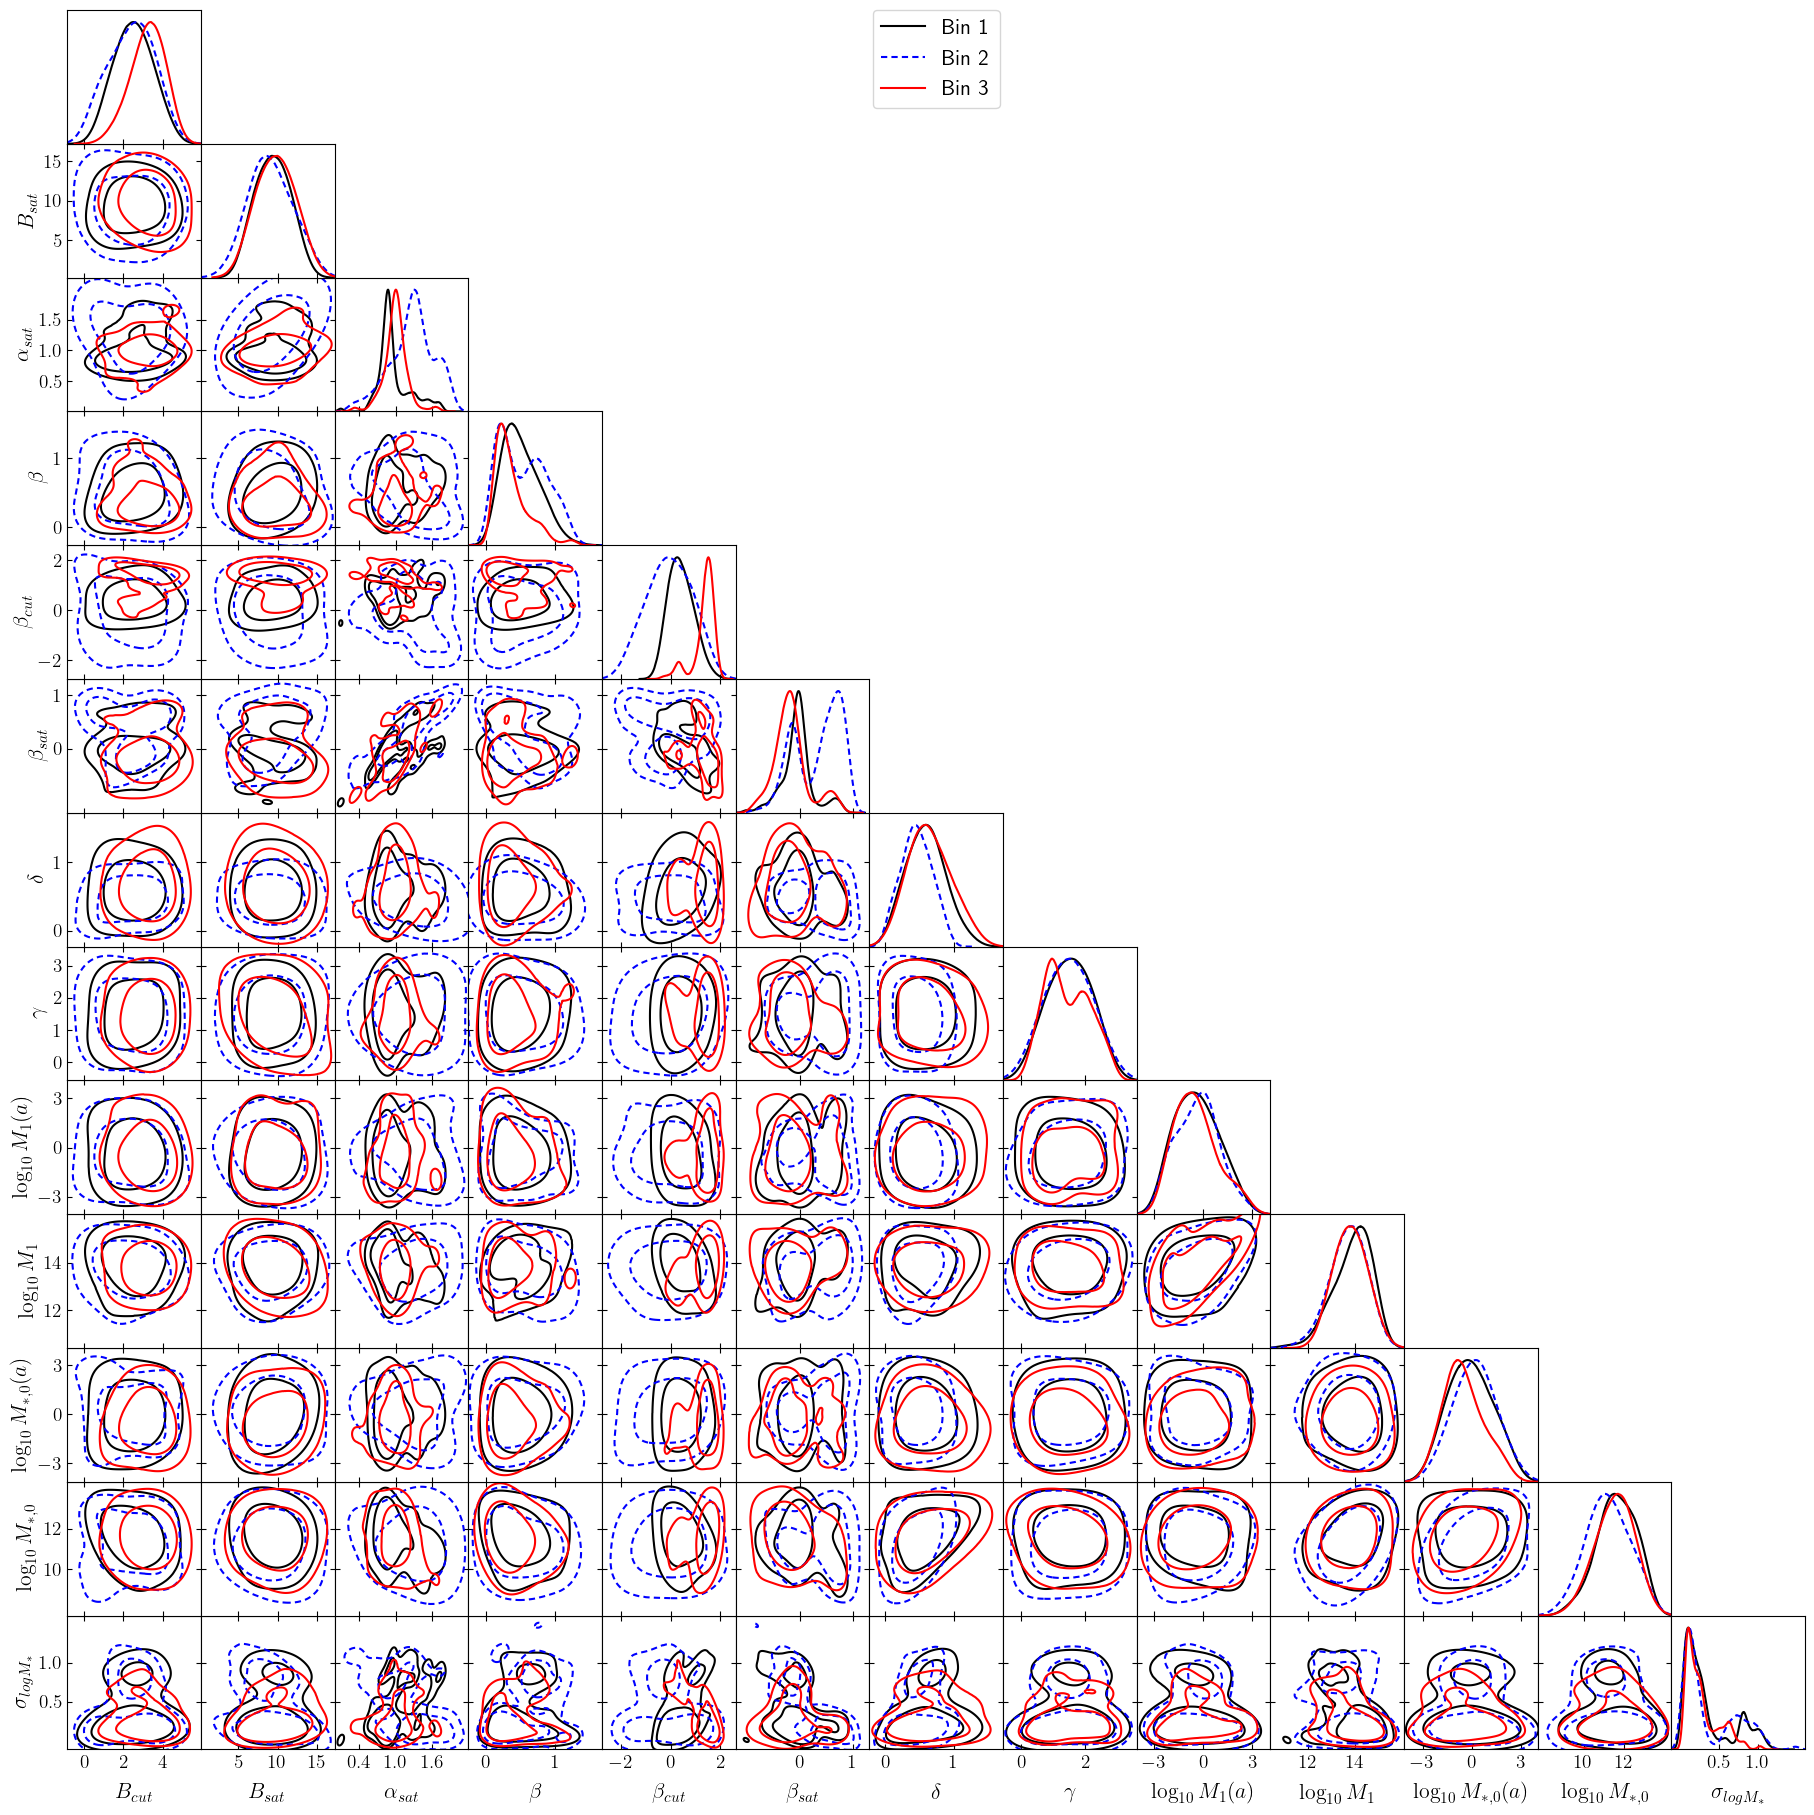

In [10]:
import re
import getdist
from getdist import plots, MCSamples
import numpy as np

# Function to standardize names by removing bin-specific suffixes
def standardize_names(names):
    """Remove _binX suffix from parameter names"""
    return [re.sub(r'_bin\d+$', '', name) for name in names]

# Function to standardize labels by removing bin-specific superscripts
def standardize_labels(labels):
    """Remove ^{X} superscripts from labels (where X is a digit)"""
    return [re.sub(r'\^\{(\d+)\}', '', label) for label in labels]

# Standardize all samples
names_std = standardize_names(names1)  # Will be same for all bins after standardization
labels_std = standardize_labels(labels1)  # Will be same for all bins after standardization

# Create MCSamples objects with standardized names and labels
samples1 = MCSamples(samples=samps1, names=names_std, labels=labels_std)
samples2 = MCSamples(samples=samps2, names=names_std, labels=labels_std)
samples3 = MCSamples(samples=samps3, names=names_std, labels=labels_std)

# Get parameter names for plotting
params = samples1.getParamNames().getRunningNames()

# Set up the plotter
g = plots.getSinglePlotter(width_inch=18.25, ratio=1.0)
g.settings.axes_fontsize = 18
g.settings.lab_fontsize = 20
g.settings.legend_fontsize = 20
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

# Define line styles for each bin
line_args = [
    {'lw': 1.5, 'color': 'black'},
    {'lw': 1.5, 'ls': '--', 'color': 'blue'},
    {'lw': 1.5, 'color': 'red'}
]

# Create the triangle plot
g.triangle_plot(
    [samples1, samples2, samples3], 
    params, 
    line_args=line_args,
    contour_lws=[1.5, 1.5, 1.5],
    filled=[False, False, False],
    contour_colors=['black', 'blue', 'red'],
    ls=['-', '--', '-'],
    legend_labels=['Bin 1', 'Bin 2', 'Bin 3']
)

import matplotlib.pyplot as pl
%matplotlib inline
pl.show()




In [45]:
def get_value(x, return_model=False):

    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    other_params_dict_vary = copy.deepcopy(other_params_dict)
    
    # for jp in range(len(sims_params_vary_names)):
    array_params_to_vary = set()
    for prior_key in prior_min_all_dict.keys():
        if '_bin' in prior_key:
            # Extract the base name (everything before '_bin')
            param_base_name = prior_key.rsplit('_bin', 1)[0]
            array_params_to_vary.add(param_base_name)
        else:
            param_base_name = prior_key
            array_params_to_vary.add(param_base_name)
    # Process each array parameter found in priors
    for param_base_name in array_params_to_vary:
        array_name = f'{param_base_name}_array'
        
        is_hod_param_array = False
        # Check if this array exists in sim_params_dict
        if (array_name not in sim_params_dict):
            if param_base_name not in other_params_dict:
                continue
            else:
                array_name = param_base_name
        else:
            is_hod_param_array = True
        
        if is_hod_param_array:
            # Start with the default array
            param_array = jnp.array(sim_params_dict[array_name])
            
            # Vary indices 1, 2, 3 (keep index 0 fixed)
            for bin_idx in range(1, 4):  # bins 1, 2, 3
                prior_key = f'{param_base_name}_bin{bin_idx}'
                
                # Check if priors exist for this parameter and bin
                if prior_key in prior_min_all_dict and prior_key in prior_max_all_dict:
                    prior_min = prior_min_all_dict[prior_key]
                    prior_max = prior_max_all_dict[prior_key]
                    
                    # Sample the parameter value
                    # param_val = Uniform(prior_key, prior_min, prior_max)
                    indsel = params_vary_names.index(prior_key)
                    param_val = x[indsel]
                    
                    # Update the array at this index
                    param_array = param_array.at[bin_idx].set(param_val)
            
            # Update sim_params_dict_vary with the modified array
            sim_params_dict_vary[array_name] = param_array
        else:
            # Single parameter in other_params_dict
            prior_key = param_base_name
            
            # Check if priors exist for this parameter
            if prior_key in prior_min_all_dict and prior_key in prior_max_all_dict:
                # prior_min = prior_min_all_dict[prior_key]
                # prior_max = prior_max_all_dict[prior_key]
                
                # Sample the parameter value
                indsel = params_vary_names.index(prior_key)
                param_val = x[indsel]
                
                # Update other_params_dict_vary with the sampled value
                other_params_dict_vary[param_base_name] = param_val

    base_test = base_class(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary)
    profiles_test = Profiles(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary, base_class_obj=base_test)
    Pkz_test = get_Pkz(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary, Profiles_obj=profiles_test)
    get_power_BCMP_test = get_Cl(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict_vary, Pkz_obj=Pkz_test)


    nell = len(l_array_sims)
    theory_combined = jnp.zeros(len(data_vec))
    for jp1 in range(analysis_dict['nz_lens_info_dict']['nbins_lens']):
        theory_val_jp1 = get_power_BCMP_test.Cl_gal_gal_tot_mat[:,jp1,jp1]
        theory_val = jnp.exp(jnp.interp(jnp.log(l_array_sims), jnp.log(get_power_BCMP_test.ell_array), jnp.log(theory_val_jp1)))
        theory_combined = theory_combined.at[jp1*nell:(jp1+1)*nell].set(theory_val)
    chi2_dof = (jnp.sum((theory_combined - data_vec)**2 / sig_total_combined**2))/(len(data_vec) - len(x))
    if return_model:
        return jnp.nan_to_num(chi2_dof, nan=1e10, posinf=1e10, neginf=1e10), get_power_BCMP_test
    else:
        return jnp.nan_to_num(chi2_dof, nan=1e10, posinf=1e10, neginf=1e10)


In [46]:
from jaxopt import ScipyBoundedMinimize
from jax import value_and_grad

# Define your optimizer
lbfgsb = ScipyBoundedMinimize(
    fun=value_and_grad(get_value), 
    value_and_grad=True, 
    method="l-bfgs-b", 
    tol=1e-9, 
    maxiter=100
)

# Set up bounds
lower_bounds = jnp.array([prior_min_all_dict[name] for name in params_vary_names])
upper_bounds = jnp.array([prior_max_all_dict[name] for name in params_vary_names])
bounds = (lower_bounds, upper_bounds)

# Initial parameters
w_init = jnp.array(xmin)

# JUST RUN IT - no gradient checking needed!
res = lbfgsb.run(w_init, bounds=bounds)

# Check results
print("Optimization result:")
print(f"  Optimal parameters: {res.params}")
print(f"  Final chi2: {res.state.fun_val}")
print(f"  Number of iterations: {res.state.iter_num}")
print(f"  Success: {res.state.success}")



Optimization result:
  Optimal parameters: [13.89587905 13.94939803 14.81467127  0.03841803  0.25694261  0.50309865
 12.66548193 11.95257027 10.57012662  1.10534999  1.10856798  0.45064976
  1.04459973  2.66293658  1.45318058  0.61134291  0.23796359  0.20385652
  3.60097331  3.75865907  1.66993993  5.20914888  7.12967362 12.8509546
 -0.20407673 -0.44166762  0.84742322  0.02169722  0.35494314  0.946778
  0.68573819  0.9506266   1.25837978  0.71785745]
  Final chi2: 12.387812671969236
  Number of iterations: 1
  Success: True


In [44]:
# Test the function at various points BEFORE running optimizer
print("Testing function at different parameter values:")

# Test at initial point
try:
    chi2 = get_value(w_init)
    print(f"Initial point: chi2 = {chi2}")
except Exception as e:
    print(f"Error at initial point: {e}")

# Test at slightly perturbed point
w_test = w_init * 1.01  # 1% increase
w_test = jnp.clip(w_test, lower_bounds, upper_bounds)
try:
    chi2 = get_value(w_test)
    print(f"Perturbed point: chi2 = {chi2}")
except Exception as e:
    print(f"Error at perturbed point: {e}")

# Test gradient
try:
    from jax import grad
    g = grad(get_value)(w_init)
    print(f"Gradient norm: {jnp.linalg.norm(g)}")
    print(f"Gradient has NaN: {jnp.any(jnp.isnan(g))}")
    print(f"Gradient: {g}")
except Exception as e:
    print(f"Error computing gradient: {e}")



Testing function at different parameter values:
Initial point: chi2 = 2989.6527260938697
Perturbed point: chi2 = 3066.3979352754122
Gradient norm: 1110.564626205401
Gradient has NaN: False
Gradient: [ 0.00000000e+00  0.00000000e+00 -1.13023371e+02  0.00000000e+00
  0.00000000e+00  1.84378451e+02  0.00000000e+00  0.00000000e+00
  5.73827438e+01  0.00000000e+00  0.00000000e+00  3.88705255e-01
  0.00000000e+00  0.00000000e+00  3.83789661e-01  0.00000000e+00
  0.00000000e+00  6.50469099e+01  0.00000000e+00  0.00000000e+00
  5.63271231e+00  0.00000000e+00  0.00000000e+00  2.52817455e+00
  0.00000000e+00  0.00000000e+00  3.49405654e+01  0.00000000e+00
  0.00000000e+00  1.20685183e+02  0.00000000e+00  0.00000000e+00
  3.04604336e+01  1.07810398e+03]


In [42]:
from jaxopt import ScipyBoundedMinimize
from jaxopt import LBFGSB



lbfgsb = ScipyBoundedMinimize(fun=value_and_grad(get_value), value_and_grad=True, method="l-bfgs-b", tol=1e-2, maxiter=100)

lower_bounds = []
upper_bounds = []
for jp in range(len(params_vary_names)):
    lower_bounds.append(prior_min_all_dict[params_vary_names[jp]])
    upper_bounds.append(prior_max_all_dict[params_vary_names[jp]])

lower_bounds = jnp.array(lower_bounds)
upper_bounds = jnp.array(upper_bounds)

bounds = (lower_bounds, upper_bounds)

w_init = jnp.array(xmin)

# Add a callback to monitor progress
def callback(state):
    print(f"Iter {state.iter_num}: chi2 = {state.fun_val:.6f}")

# Note: jaxopt doesn't support callbacks directly in ScipyBoundedMinimize
# But you can check the state after completion
res = lbfgsb.run(w_init, bounds=bounds)

print("\nOptimization completed!")
print(f"Initial chi2: {get_value(w_init)}")
print(f"Final chi2: {res.state.fun_val}")
print(f"Improvement: {get_value(w_init) - res.state.fun_val}")


TracerBoolConversionError: Attempted boolean conversion of traced array with shape bool[].
The error occurred while tracing the function value_and_grad_without_aux at /mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/jaxopt/_src/base.py:101 for jit. This concrete value was not available in Python because it depends on the value of the argument a[0].
See https://jax.readthedocs.io/en/latest/errors.html#jax.errors.TracerBoolConversionError

In [ ]:
# Get detailed state information
state = lbfgsb.init_state(w_init)
print("Initial state:", state)

# Run one step manually to see what happens
state = lbfgsb.update(w_init, state)
print("State after 1 step:", state)
print("Parameters after 1 step:", state.params if hasattr(state, 'params') else 'N/A')


In [28]:
xmin



[13.895879049684465,
 13.94939802695827,
 14.81467126737661,
 0.03841802695676144,
 0.2569426052070485,
 0.5030986521196319,
 12.665481930328312,
 11.952570273826094,
 10.570126624519679,
 1.1053499887288654,
 1.1085679793809509,
 0.4506497635630673,
 1.0445997331485566,
 2.662936582929728,
 1.4531805824122097,
 0.6113429119382512,
 0.23796359116052912,
 0.20385651870159405,
 3.600973313880773,
 3.7586590701120013,
 1.6699399315388015,
 5.209148882308519,
 7.129673616374562,
 12.850954602369876,
 -0.20407673462926879,
 -0.4416676178300274,
 0.8474232196165722,
 0.021697218889408676,
 0.3549431447500254,
 0.9467780032784388,
 0.6857381874670259,
 0.9506266019217613,
 1.2583797750940366,
 0.7178574475564585]

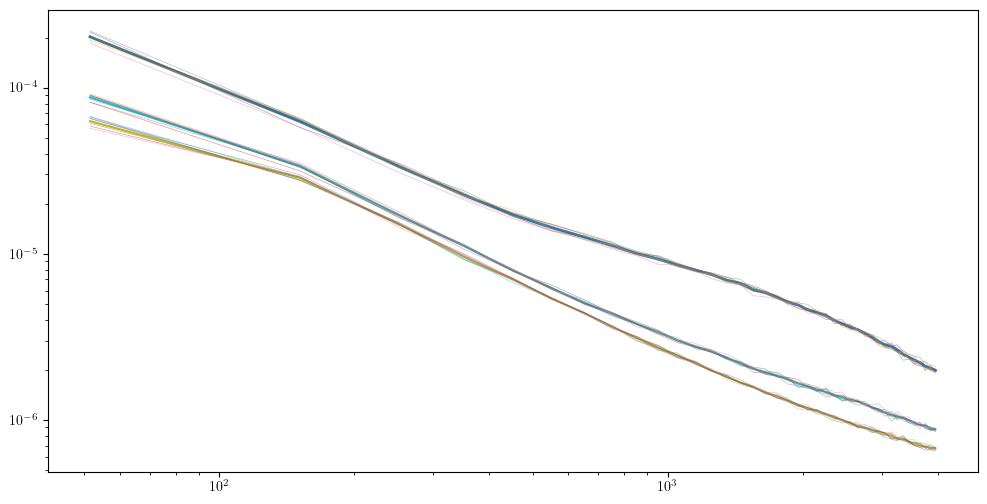

In [33]:
Cl_gg_sims0_all = []
Cl_gg_sims1_all = []
Cl_gg_sims2_all = []
Ngal_z0_all = []
Ngal_z1_all = []
Ngal_z2_all = []

nsims = 8
ldir = '/mnt/ceph/users/spandey/abacus'
for ji in range(nsims):
    # if ji == 0:
    df_sims = pk.load(open(f'{ldir}/abacus_LRG_nz_Clgg_v3_AbacusSummit_base_c000_ph00{ji}.pkl','rb'))
    Cls_sims = df_sims['Cl_gg_all']
    l_array_sims = jnp.array(Cls_sims['l_array'])
    Cl_gg_sims0 = jnp.array(Cls_sims['z0.300_0.400'])
    Cl_gg_sims1 = jnp.array(Cls_sims['z0.450_0.575'])
    Cl_gg_sims2 = jnp.array(Cls_sims['z0.650_0.800'])
    Cl_gg_sims0_all.append(Cl_gg_sims0)
    Cl_gg_sims1_all.append(Cl_gg_sims1)
    Cl_gg_sims2_all.append(Cl_gg_sims2)

    Ngal_z0_all.append(df_sims['Ngal_all']['z0.300_0.400'])
    Ngal_z1_all.append(df_sims['Ngal_all']['z0.450_0.575'])
    Ngal_z2_all.append(df_sims['Ngal_all']['z0.650_0.800'])
    


Ngal_all_final = {}
Ngal_all_final['z0.300_0.400'] = np.sum(np.array(Ngal_z0_all), axis=0)
Ngal_all_final['z0.450_0.575'] = np.sum(np.array(Ngal_z1_all), axis=0)
Ngal_all_final['z0.650_0.800'] = np.sum(np.array(Ngal_z2_all), axis=0)


Cl_gg_sims0 = jnp.mean(jnp.array(Cl_gg_sims0_all), axis=0)
Cl_gg_sims1 = jnp.mean(jnp.array(Cl_gg_sims1_all), axis=0)
Cl_gg_sims2 = jnp.mean(jnp.array(Cl_gg_sims2_all), axis=0)

Cls_sims_final = {}
Cls_sims_final['l_array'] = l_array_sims
Cls_sims_final['z0.300_0.400'] = Cl_gg_sims0
Cls_sims_final['z0.450_0.575'] = Cl_gg_sims1
Cls_sims_final['z0.650_0.800'] = Cl_gg_sims2

pl.figure(figsize=(12,6))
pl.plot(l_array_sims, Cl_gg_sims0, lw=2.0)
for ji in range(nsims):
    pl.plot(l_array_sims, Cl_gg_sims0_all[ji], lw=0.5, alpha=0.5)

pl.plot(l_array_sims, Cl_gg_sims1)
for ji in range(nsims):
    pl.plot(l_array_sims, Cl_gg_sims1_all[ji], lw=0.5, alpha=0.5)
pl.plot(l_array_sims, Cl_gg_sims2)
for ji in range(nsims):
    pl.plot(l_array_sims, Cl_gg_sims2_all[ji], lw=0.5, alpha=0.5)
pl.xscale('log')
pl.yscale('log')
# pl.xlim(1000,4000)
# pl.ylim(5e-7, 5e-6)
pl.show()   




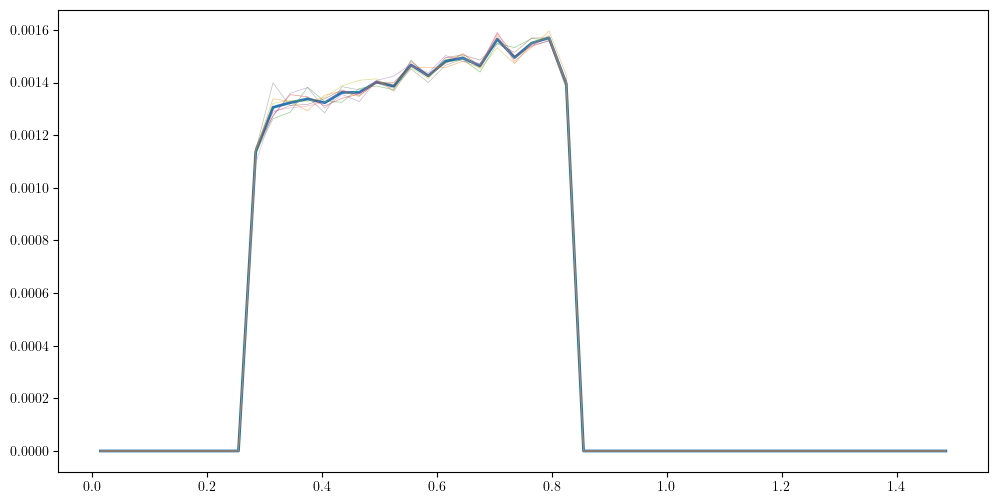

In [34]:
nbar_comoving_all = []
# nsims = 6
ldir = '/mnt/ceph/users/spandey/abacus'
for ji in range(nsims):
    # if ji == 0:
    df_sims = pk.load(open(f'{ldir}/abacus_LRG_nz_Clgg_v3_AbacusSummit_base_c000_ph00{ji}.pkl','rb'))
    nbar_comoving_all.append(df_sims['nbar_comoving'])
    zcens_comoving = df_sims['zcens_comoving']
nbar_comoving = jnp.mean(jnp.array(nbar_comoving_all), axis=0)

pl.figure(figsize=(12,6))
pl.plot(zcens_comoving, nbar_comoving, lw=2.0)
for ji in range(nsims):
    pl.plot(zcens_comoving, nbar_comoving_all[ji], lw=0.5, alpha=0.5)



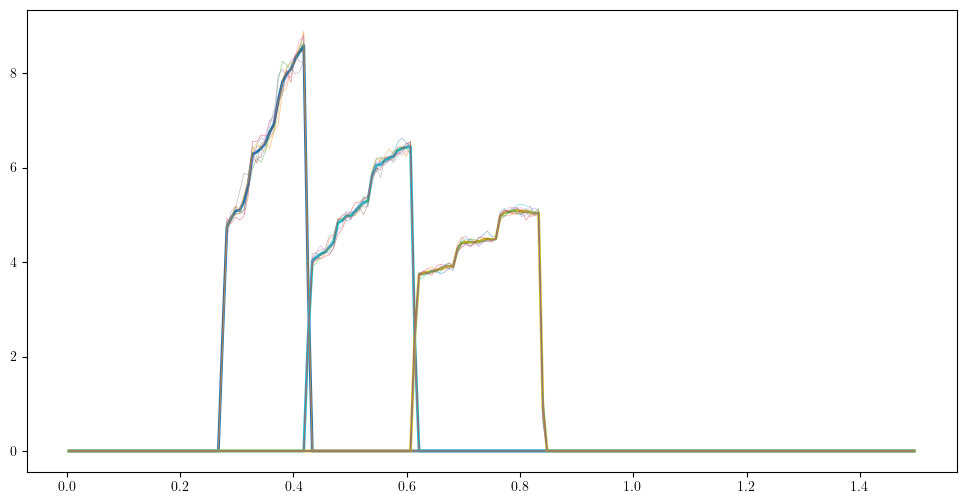

In [35]:
nz_z0_all = []
nz_z1_all = []
nz_z2_all = []
# nsims = 6
ldir = '/mnt/ceph/users/spandey/abacus'
for ji in range(nsims):
    # if ji == 0:
    df_sims = pk.load(open(f'{ldir}/abacus_LRG_nz_Clgg_v3_AbacusSummit_base_c000_ph00{ji}.pkl','rb'))
    # print(df_sims['nz_gal_all'].keys())
    nz_sims = df_sims['nz_gal_all']
    z_array_sims = jnp.array(nz_sims['z_array'])
    nz_z0 = jnp.array(nz_sims['z0.300_0.400'])
    nz_z1 = jnp.array(nz_sims['z0.450_0.575'])
    nz_z2 = jnp.array(nz_sims['z0.650_0.800'])
    nz_z0_all.append(nz_z0)
    nz_z1_all.append(nz_z1)
    nz_z2_all.append(nz_z2)

nz_z0 = jnp.mean(jnp.array(nz_z0_all), axis=0)
nz_z1 = jnp.mean(jnp.array(nz_z1_all), axis=0)
nz_z2 = jnp.mean(jnp.array(nz_z2_all), axis=0)

nz_sims_final = {}
nz_sims_final['z_array'] = z_array_sims
nz_sims_final['z0.300_0.400'] = nz_z0
nz_sims_final['z0.450_0.575'] = nz_z1
nz_sims_final['z0.650_0.800'] = nz_z2

pl.figure(figsize=(12,6))
pl.plot(z_array_sims, nz_z0, lw=2.0)
for ji in range(nsims):
    pl.plot(z_array_sims, nz_z0_all[ji], lw=0.5, alpha=0.5)
pl.plot(z_array_sims, nz_z1, lw=2.0)
for ji in range(nsims):
    pl.plot(z_array_sims, nz_z1_all[ji], lw=0.5, alpha=0.5)
pl.plot(z_array_sims, nz_z2, lw=2.0)
for ji in range(nsims):
    pl.plot(z_array_sims, nz_z2_all[ji], lw=0.5, alpha=0.5)


In [ ]:
    # import pickle as pk
    # with open(f'/mnt/ceph/users/spandey/abacus/abacus_LRG_nz_Clgg_v3_AbacusSummit_base_c000_ph00{ji}.pkl', 'wb') as f:
    #     pk.dump({'nz_gal_all': nz_gal_all, 'Cl_gg_all': Cl_gg_all,'Ngal_all':Ngal_all,  
    #             'nbar_comoving': nbar_comoving, 'zcens_comoving': zcens_comoving,
    #             'zmin_all': zmin_all, 'zmax_all': zmax_all, 'zvals': zvals}, f)

In [133]:
saved_final = {}
saved_final['Cl_gg_all'] = Cls_sims_final
saved_final['Ngal_all'] = Ngal_all_final
saved_final['nz_gal_all'] = nz_sims_final
saved_final['nbar_comoving'] = nbar_comoving
saved_final['zcens_comoving'] = zcens_comoving
saved_final['zvals'] = df_sims['zvals']
saved_final['zmin_all'] = df_sims['zmin_all']
saved_final['zmax_all'] = df_sims['zmax_all']
with open(f'{ldir}/abacus_LRG_nz_Clgg_v3_combined_{nsims}sims.pkl', 'wb') as f:
    pk.dump(saved_final, f)
